In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load the dataset. I will used trimmed housing dataset from the previous project
df = pd.read_csv('../../Exercise_project_1\Regression_dataset\housing_trimmed_variables.csv')
df.head()


original_size = df.shape[0]
df_filtered = df.copy()

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\svetl\AppData\Local\Temp\ipykernel_15700\1432849896.py:2: SyntaxWarning: invalid escape sequence '\R'
  df = pd.read_csv('../../Exercise_project_1\Regression_dataset\housing_trimmed_variables.csv')


C:\Users\svetl\AppData\Local\Temp\ipykernel_15700\2683018153.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['median_income'])
C:\Users\svetl\AppData\Local\Temp\ipykernel_15700\2683018153.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['distance_to_nearest_city'])


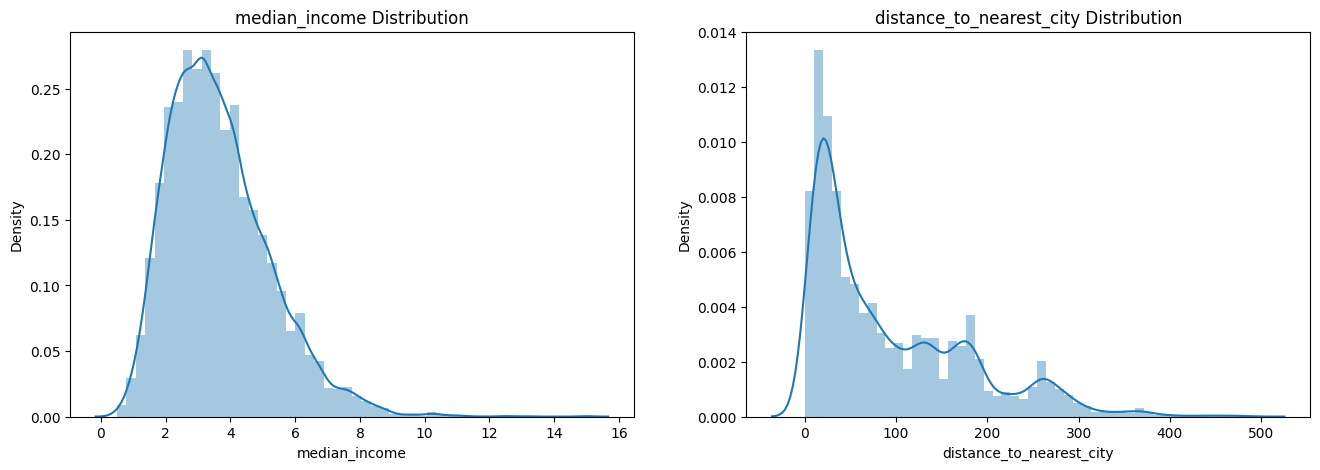

In [25]:
# Visualizing the Data Distribution
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.distplot(df['median_income'])
plt.title('median_income Distribution')

plt.subplot(1,2,2)
sns.distplot(df['distance_to_nearest_city'])
plt.title('distance_to_nearest_city Distribution')

plt.show()

C:\Users\svetl\AppData\Local\Temp\ipykernel_15700\3312326914.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['total_rooms'])
C:\Users\svetl\AppData\Local\Temp\ipykernel_15700\3312326914.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['housing_median_age'])


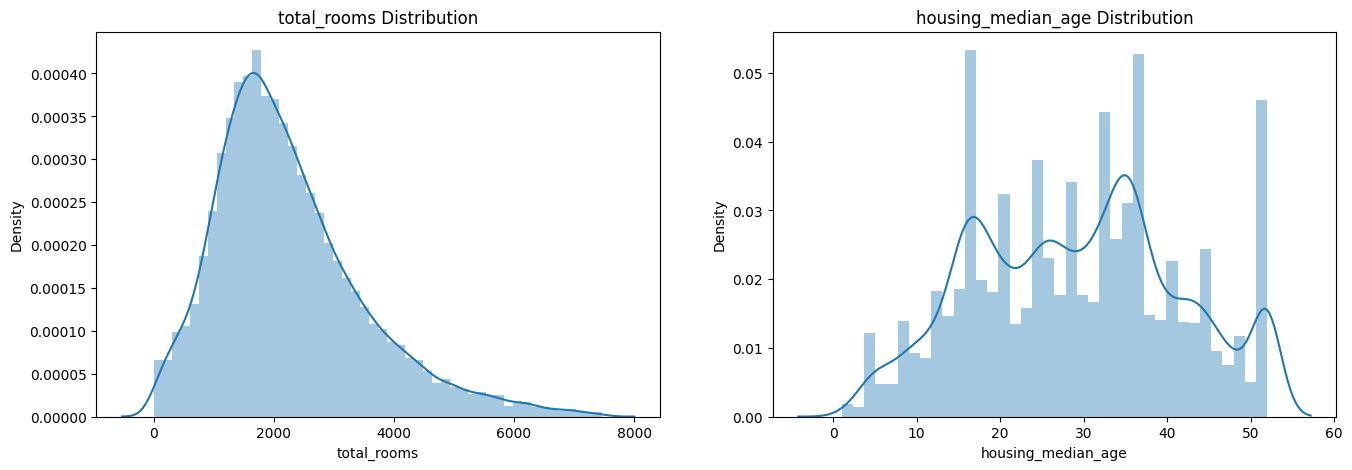

In [26]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['total_rooms'])
plt.title('total_rooms Distribution')


plt.subplot(1,2,2)
sns.distplot(df['housing_median_age'])
plt.title('housing_median_age Distribution')


plt.show()


Detecting outliers in: total_rooms
Lower limit: -834.125
Upper limit: 5128.875
Outliers below lower limit: 0
Outliers above upper limit: 642
Total outliers detected: 642
Rows before trimming: 18322
Rows after trimming: 17680
Outliers removed for total_rooms: 642

Detecting outliers in: median_income
Lower limit: -0.5547499999999999
Upper limit: 7.6328499999999995
Outliers below lower limit: 0
Outliers above upper limit: 343
Total outliers detected: 343
Rows before trimming: 17680
Rows after trimming: 17376
Outliers removed for median_income: 304

Detecting outliers in: distance_to_nearest_city
Lower limit: -159.38
Upper limit: 326.92
Outliers below lower limit: 0
Outliers above upper limit: 257
Total outliers detected: 257
Rows before trimming: 17376
Rows after trimming: 17122
Outliers removed for distance_to_nearest_city: 254

Detecting outliers in: housing_median_age
Lower limit: -8.0
Upper limit: 64.0
Outliers below lower limit: 0
Outliers above upper limit: 0
Total outliers detect

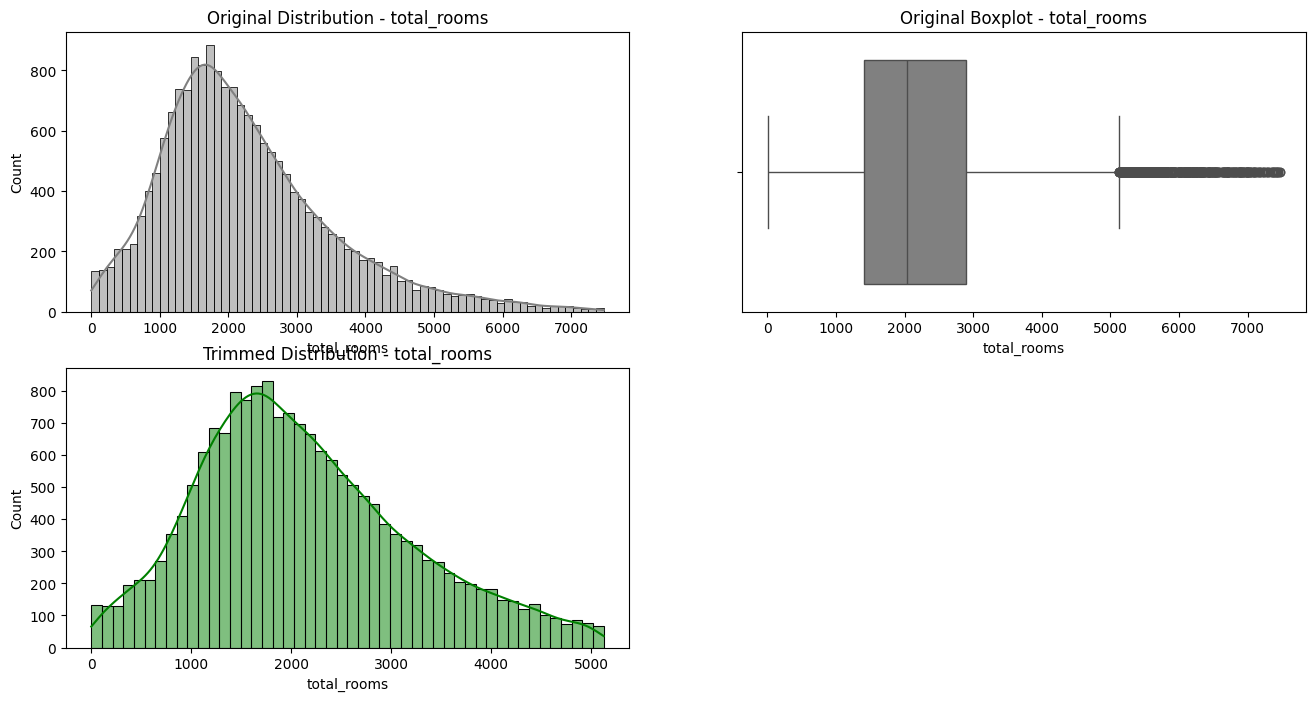

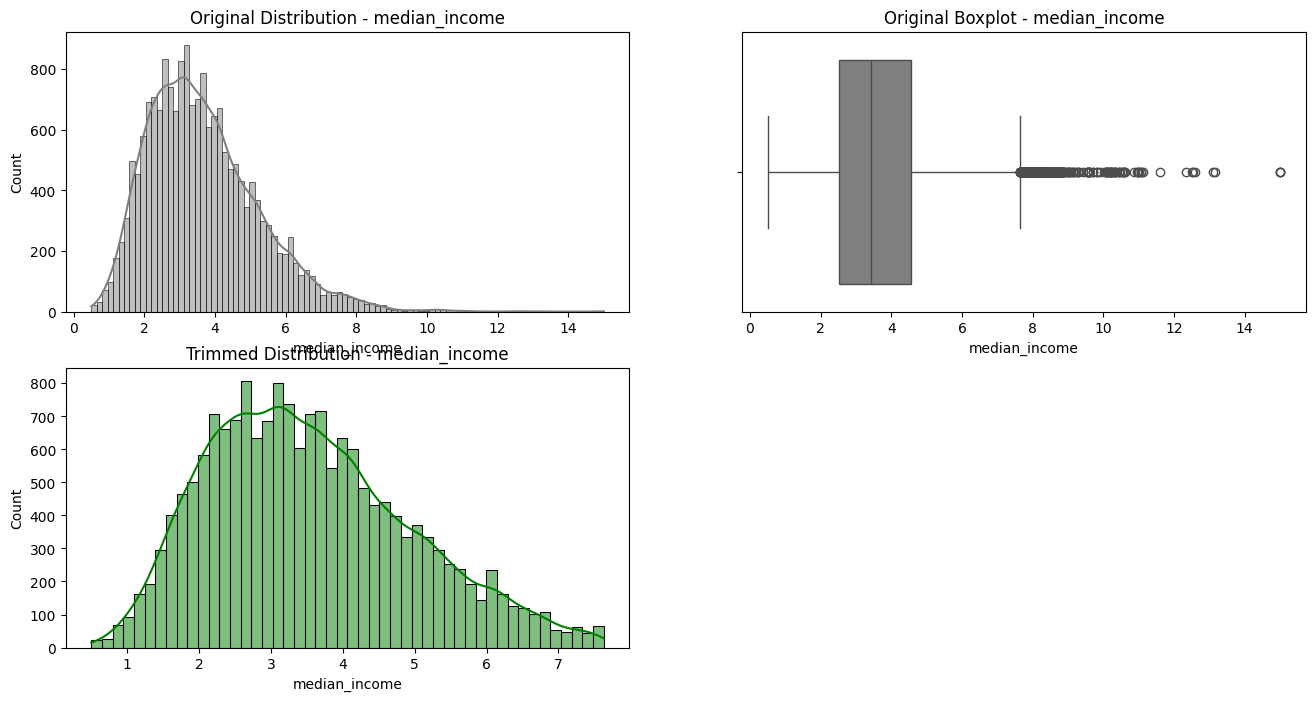

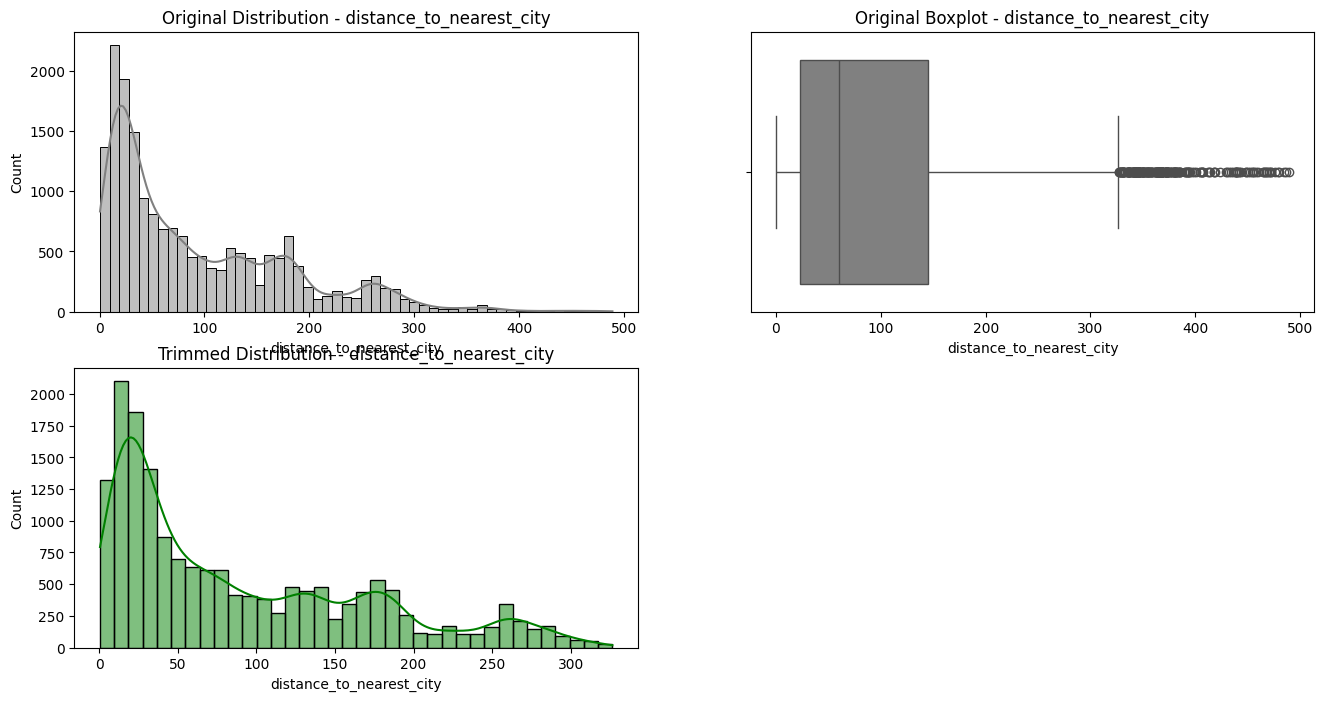

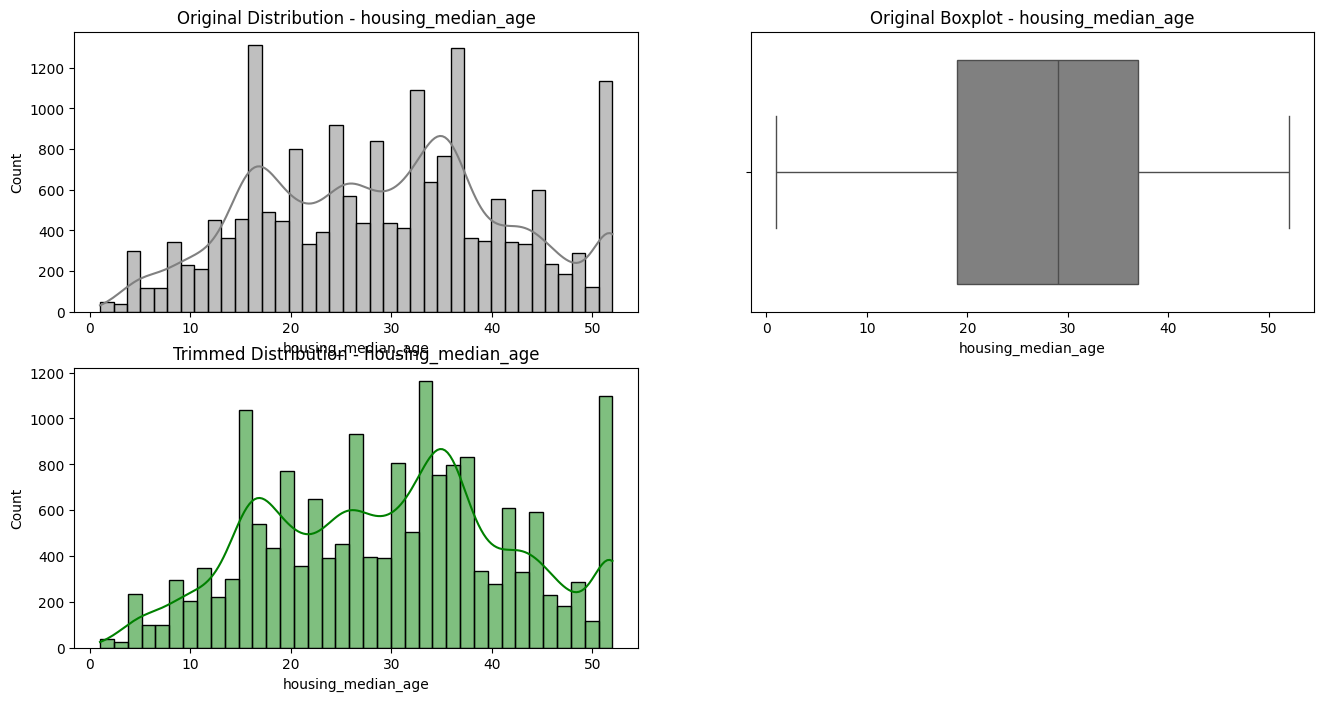

In [27]:
support_vars = ['total_rooms', 'median_income', 'distance_to_nearest_city',"housing_median_age"]

for var in support_vars:
    print(f"\nDetecting outliers in: {var}")

    # Step 1: Calculate IQR
    percentile25 = df[var].quantile(0.25)
    percentile75 = df[var].quantile(0.75)
    iqr = percentile75 - percentile25

    lower_limit = percentile25 - 1.5 * iqr
    upper_limit = percentile75 + 1.5 * iqr

    print("Lower limit:", lower_limit)
    print("Upper limit:", upper_limit)

    # Step 2: Identify outliers
    outliers_below = df[df[var] < lower_limit]
    outliers_above = df[df[var] > upper_limit]
    total_outliers = len(outliers_below) + len(outliers_above)

    print(f"Outliers below lower limit: {len(outliers_below)}")
    print(f"Outliers above upper limit: {len(outliers_above)}")
    print(f"Total outliers detected: {total_outliers}")

    # Step 3: Removing Outliers (Trimming):
    before_rows = df_filtered.shape[0]
    df_filtered = df_filtered[(df_filtered[var] >= lower_limit) & (df_filtered[var] <= upper_limit)]
    after_rows = df_filtered.shape[0]
    removed = before_rows - after_rows

    print(f"Rows before trimming: {before_rows}")
    print(f"Rows after trimming: {after_rows}")
    print(f"Outliers removed for {var}: {removed}")

    # Step 3: Plot before and after trimming
    plt.figure(figsize=(16, 8))

    # Original distribution
    plt.subplot(2, 2, 1)
    sns.histplot(df[var], kde=True, color='gray')
    plt.title(f'Original Distribution - {var}')

    # Original boxplot
    plt.subplot(2, 2, 2)
    sns.boxplot(x=df[var], color='gray')
    plt.title(f'Original Boxplot - {var}')

    # Trimmed distribution
    plt.subplot(2, 2, 3)
    sns.histplot(df_filtered[var], kde=True, color='green')
    plt.title(f'Trimmed Distribution - {var}')

In [28]:
final_size = df_filtered.shape[0]
removed_rows = original_size - final_size

#Save the final df:
df_filtered.to_csv("housing_after_iqr.csv", index=False)


print("Original dataset size:", df.shape[0])
print("Final dataset size after trimming:", df_filtered.shape[0])
print("Total rows removed by IQR:", df.shape[0] - df_filtered.shape[0])

Original dataset size: 18322
Final dataset size after trimming: 17122
Total rows removed by IQR: 1200
